## 0. Import and Setup

In [1]:
# Setup and imports
import sys
import json
import sqlite3
from pathlib import Path
from pprint import pprint

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

Project root: /home/feiy/Role-SQL-benchmark


In [2]:
# Load environment and initialize Oracle
from dotenv import load_dotenv
import os

load_dotenv(project_root / '.env')

# Check available API keys
api_keys = {
    'OPENAI_API_KEY': bool(os.getenv('OPENAI_API_KEY')),
    'DEEPSEEK_API_KEY': bool(os.getenv('DEEPSEEK_API_KEY')),
    'DEEPINFRA_API_KEY': bool(os.getenv('DEEPINFRA_API_KEY')),
}
print("Available API keys:")
for k, v in api_keys.items():
    print(f"  {k}: {'✓' if v else '✗'}")

Available API keys:
  OPENAI_API_KEY: ✓
  DEEPSEEK_API_KEY: ✓
  DEEPINFRA_API_KEY: ✓


In [3]:
# Initialize LLM Oracle
from src.llm_oracle import Oracle

# Choose model based on available keys (prefer DeepSeek for cost efficiency)
if os.getenv('DEEPSEEK_API_KEY'):
    MODEL = "deepseek-chat"
    API_KEY = os.getenv('DEEPSEEK_API_KEY')
elif os.getenv('OPENAI_API_KEY'):
    MODEL = "gpt-4o-mini"
    API_KEY = os.getenv('OPENAI_API_KEY')
else:
    raise ValueError("No API key available!")

oracle = Oracle(model=MODEL, apikey=API_KEY)
print(f"Using model: {MODEL}")

Using model: deepseek-chat


/home/feiy/anaconda3/envs/llm4db/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Sample Database Schema

We'll use a BIRD database with interesting column structure for testing.

In [4]:
# Import shared policy utility functions
from src.role_evaluator.quality_metrics import RoleQualityEvaluator

# Convenience aliases for the static methods
count_policy_columns = RoleQualityEvaluator.count_policy_columns
has_wildcard_policy = RoleQualityEvaluator.has_wildcard_policy

def get_schema_from_sqlite(db_path: str) -> dict:
    """Extract detailed schema from SQLite database."""
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    # Get all tables
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%'")
    tables = [row[0] for row in cursor.fetchall()]
    
    schema = {}
    for table in tables:
        cursor.execute(f"PRAGMA table_info(`{table}`)")
        columns = cursor.fetchall()
        
        cursor.execute(f"PRAGMA foreign_key_list(`{table}`)")
        fks = {row[3]: f"{row[2]}.{row[4]}" for row in cursor.fetchall()}
        
        schema[table] = {
            'columns': [
                {
                    'name': col[1],
                    'type': col[2] or 'TEXT',
                    'pk': col[5] == 1,
                    'not_null': col[3] == 1,
                    'fk': fks.get(col[1])
                }
                for col in columns
            ]
        }
    
    conn.close()
    return schema

def format_schema_for_prompt(schema: dict, db_name: str) -> str:
    """Format schema as text for LLM prompt."""
    lines = [f"Database: {db_name}\n"]
    
    for table, info in schema.items():
        lines.append(f"Table: {table}")
        lines.append("Columns:")
        for col in info['columns']:
            constraints = []
            if col['pk']:
                constraints.append("PRIMARY KEY")
            if col['not_null'] and not col['pk']:
                constraints.append("NOT NULL")
            if col['fk']:
                constraints.append(f"FK -> {col['fk']}")
            
            constraint_str = f" [{', '.join(constraints)}]" if constraints else ""
            lines.append(f"  - {col['name']} ({col['type']}){constraint_str}")
        lines.append("")
    
    return "\n".join(lines)

In [5]:
# Load a sample BIRD database - use the latest 2025 version
bird_db_dir = project_root / 'data' / 'Bird' / 'dev_20251106' / 'dev_databases'

# List available databases
available_dbs = [d.name for d in bird_db_dir.iterdir() if d.is_dir()]
print(f"Available BIRD databases ({len(available_dbs)}):")
for db in sorted(available_dbs)[:10]:
    print(f"  - {db}")
print("  ...")

Available BIRD databases (11):
  - california_schools
  - card_games
  - codebase_community
  - debit_card_specializing
  - european_football_2
  - financial
  - formula_1
  - student_club
  - superhero
  - thrombosis_prediction
  ...


In [6]:
# Select a database with moderate complexity
# 'california_schools' has tables with sensitive-looking columns
TEST_DB = "california_schools"
db_path = bird_db_dir / TEST_DB / f"{TEST_DB}.sqlite"

print(f"Loading schema from: {db_path}")
schema = get_schema_from_sqlite(str(db_path))

print(f"\nTables: {list(schema.keys())}")
for table, info in schema.items():
    print(f"\n{table}: {len(info['columns'])} columns")
    for col in info['columns'][:5]:
        print(f"  - {col['name']} ({col['type']})")
    if len(info['columns']) > 5:
        print(f"  ... and {len(info['columns']) - 5} more")

Loading schema from: /home/feiy/Role-SQL-benchmark/data/Bird/dev_20251106/dev_databases/california_schools/california_schools.sqlite

Tables: ['frpm', 'satscores', 'schools']

frpm: 29 columns
  - CDSCode (TEXT)
  - Academic Year (TEXT)
  - County Code (TEXT)
  - District Code (INTEGER)
  - School Code (TEXT)
  ... and 24 more

satscores: 11 columns
  - cds (TEXT)
  - rtype (TEXT)
  - sname (TEXT)
  - dname (TEXT)
  - cname (TEXT)
  ... and 6 more

schools: 49 columns
  - CDSCode (TEXT)
  - NCESDist (TEXT)
  - NCESSchool (TEXT)
  - StatusType (TEXT)
  - County (TEXT)
  ... and 44 more


In [7]:
# Format schema for prompt
schema_text = format_schema_for_prompt(schema, TEST_DB)
print(schema_text[:2000])
print(f"\n... (total {len(schema_text)} characters)")

Database: california_schools

Table: frpm
Columns:
  - CDSCode (TEXT) [PRIMARY KEY, FK -> schools.CDSCode]
  - Academic Year (TEXT)
  - County Code (TEXT)
  - District Code (INTEGER)
  - School Code (TEXT)
  - County Name (TEXT)
  - District Name (TEXT)
  - School Name (TEXT)
  - District Type (TEXT)
  - School Type (TEXT)
  - Educational Option Type (TEXT)
  - NSLP Provision Status (TEXT)
  - Charter School (Y/N) (INTEGER)
  - Charter School Number (TEXT)
  - Charter Funding Type (TEXT)
  - IRC (INTEGER)
  - Low Grade (TEXT)
  - High Grade (TEXT)
  - Enrollment (K-12) (REAL)
  - Free Meal Count (K-12) (REAL)
  - Percent (%) Eligible Free (K-12) (REAL)
  - FRPM Count (K-12) (REAL)
  - Percent (%) Eligible FRPM (K-12) (REAL)
  - Enrollment (Ages 5-17) (REAL)
  - Free Meal Count (Ages 5-17) (REAL)
  - Percent (%) Eligible Free (Ages 5-17) (REAL)
  - FRPM Count (Ages 5-17) (REAL)
  - Percent (%) Eligible FRPM (Ages 5-17) (REAL)
  - 2013-14 CALPADS Fall 1 Certification Status (INTEGER)

Ta

## 2. Load Prompts from External Modules

Prompts are now defined in `configs/column_level_prompts.py`.
- **JSON format** is used (more structured, requires max_tokens=4000)
- Parser auto-detects format and handles both JSON and Plain Text

In [8]:
# Reload modules to get latest changes
import importlib
import configs.column_level_prompts
import src.role_parser.column_level_parser
importlib.reload(configs.column_level_prompts)
importlib.reload(src.role_parser.column_level_parser)

# Import prompts and parser from external modules
from configs.column_level_prompts import (
    COLUMN_LEVEL_SYSTEM_PROMPT, 
    COLUMN_LEVEL_USER_PROMPT_TEMPLATE,
    DEFAULT_MAX_TOKENS
)
from src.role_parser import parse_column_level_roles, validate_roles_against_schema

print("✓ Loaded from external modules:")
print(f"  - COLUMN_LEVEL_SYSTEM_PROMPT ({len(COLUMN_LEVEL_SYSTEM_PROMPT)} chars)")
print(f"  - COLUMN_LEVEL_USER_PROMPT_TEMPLATE")
print(f"  - DEFAULT_MAX_TOKENS = {DEFAULT_MAX_TOKENS}")
print(f"  - parse_column_level_roles (auto-detects JSON/Text)")
print(f"  - validate_roles_against_schema")

print("\n--- System Prompt Preview ---")
print(COLUMN_LEVEL_SYSTEM_PROMPT[:500])
print("...")

✓ Loaded from external modules:
  - COLUMN_LEVEL_SYSTEM_PROMPT (2734 chars)
  - COLUMN_LEVEL_USER_PROMPT_TEMPLATE
  - DEFAULT_MAX_TOKENS = 4000
  - parse_column_level_roles (auto-detects JSON/Text)
  - validate_roles_against_schema

--- System Prompt Preview ---
You are a database security expert specializing in fine-grained Role-Based Access Control (RBAC).
Your job is to read a relational database schema and propose a COHERENT set of roles with COLUMN-LEVEL permissions.

Key goals:
- Minimize role count while covering real-world workflows (decide number of roles according to real world scenario).
- Each role must be clearly related to others (same scenario, complementary duties).
- Enforce least-privilege at the COLUMN level (specify which columns eac
...


## [Archived] Single-Sample Experiments

The following code block contains single sample test code for debugging prompt and parser.
**Commented out. For production, skip to Section 8 for batch processing.**

In [9]:
# ============================================================
# [ARCHIVED] Single sample experiment code - commented out, skip this cell
# ============================================================
# The following code is for testing and debugging a single database
# For production, skip to Section 8 for batch processing

'''
# --- 3. Generate Column-Level Roles (Single DB) ---
print("Generating column-level roles...")
user_prompt = COLUMN_LEVEL_USER_PROMPT_TEMPLATE.format(schema_content=schema_text)
response = oracle.query(
    prompt_sys=COLUMN_LEVEL_SYSTEM_PROMPT,
    prompt_user=user_prompt,
    temp=0.3, top_p=0.9,
    max_completion_tokens=DEFAULT_MAX_TOKENS
)
llm_response = response['answer']
print(f"Response length: {len(llm_response)} chars")

# --- 4. Parse and Validate ---
from src.role_parser.column_level_parser import parse_column_level_roles
parsed_roles = parse_column_level_roles(llm_response)
print(f"Parsed {len(parsed_roles)} roles")

validation = validate_roles_against_schema(parsed_roles, str(db_path))
print(f"Valid: {validation['valid_roles']}/{validation['total_roles']}")

# --- 5. Show Results ---
for role in parsed_roles:
    print(f"  - {role['role']}: {len(role.get('columns', {}))} tables")

# --- 6. Compare with Table-Level ---
from configs.prompts import SYSTEM_PROMPT as TABLE_LEVEL_PROMPT, USER_PROMPT_TEMPLATE
table_level_response = oracle.query(
    prompt_sys=TABLE_LEVEL_PROMPT,
    prompt_user=USER_PROMPT_TEMPLATE.format(schema_content=schema_text),
    temp=0.3, top_p=0.9
)
print("Table-Level Response:", table_level_response['answer'][:500])

# --- 7. Save Single DB Result ---
def convert_to_assignment_format(parsed_roles, db_name):
    return {"assignments": {db_name: [
        {"role": r["role"], "description": r.get("description", ""), "policy": r.get("columns", {})}
        for r in parsed_roles
    ]}}

column_level_assignments = convert_to_assignment_format(parsed_roles, TEST_DB)
output_file = project_root / 'outputs' / 'column_level_role_assignments.json'
with open(output_file, 'w') as f:
    json.dump(column_level_assignments, f, indent=2, ensure_ascii=False)
print(f"Saved to: {output_file}")
'''

print("⏭️ This cell is commented out. Skip to Section 8 for batch processing.")

⏭️ This cell is commented out. Skip to Section 8 for batch processing.


## 3. Batch Process All BIRD Databases

Generate column-level role assignments for all BIRD databases with parallel processing.

In [10]:
# Batch processing configuration
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm

# Configuration
WORKERS = 40
SAMPLES = 100  # 0 for all databases
MAX_TOKENS = DEFAULT_MAX_TOKENS

# Get all BIRD databases
all_dbs = [d.name for d in bird_db_dir.iterdir() if d.is_dir()]
if SAMPLES > 0:
    all_dbs = all_dbs[:SAMPLES]

print(f"Configuration:")
print(f"  Workers: {WORKERS}")
print(f"  Databases: {len(all_dbs)}")
print(f"  Max tokens: {MAX_TOKENS}")
print(f"  Model: {MODEL}")
print(f"\nDatabases to process:")
for db in all_dbs:
    print(f"  - {db}")

Configuration:
  Workers: 40
  Databases: 11
  Max tokens: 4000
  Model: deepseek-chat

Databases to process:
  - superhero
  - thrombosis_prediction
  - student_club
  - toxicology
  - california_schools
  - debit_card_specializing
  - card_games
  - codebase_community
  - formula_1
  - european_football_2
  - financial


In [11]:
# Helper functions for batch processing

def process_single_database(db_name: str) -> dict:
    """Process a single database and return role assignments."""
    db_path = bird_db_dir / db_name / f"{db_name}.sqlite"
    
    if not db_path.exists():
        return {"database": db_name, "status": "error", "error": f"Database not found"}
    
    try:
        # Extract schema
        db_schema = get_schema_from_sqlite(str(db_path))
        db_schema_text = format_schema_for_prompt(db_schema, db_name)
        
        # Generate roles via LLM
        user_prompt = COLUMN_LEVEL_USER_PROMPT_TEMPLATE.format(schema_content=db_schema_text)
        
        response = oracle.query(
            prompt_sys=COLUMN_LEVEL_SYSTEM_PROMPT,
            prompt_user=user_prompt,
            temp=0.3,
            top_p=0.9,
            max_completion_tokens=MAX_TOKENS
        )
        
        llm_response = response['answer']
        usage = response.get('usage', {})
        
        # Parse response
        roles = parse_column_level_roles(llm_response)
        
        if not roles:
            return {
                "database": db_name,
                "status": "parse_error",
                "error": "Failed to parse LLM response",
                "raw_response": llm_response[:300]
            }
        
        # Validate against schema
        validation = validate_roles_against_schema(roles, str(db_path))
        
        # Convert to target format
        assignments = []
        for role in roles:
            assignments.append({
                "role": role["role"],
                "description": role.get("description", ""),
                "policy": role.get("columns", {})
            })
        
        return {
            "database": db_name,
            "status": "success",
            "roles_count": len(assignments),
            "valid_roles": validation['valid_roles'],
            "all_valid": validation['all_valid'],
            "assignments": assignments,
            "usage": usage
        }
        
    except Exception as e:
        return {
            "database": db_name,
            "status": "error",
            "error": str(e)
        }

print("✓ Helper functions defined")

✓ Helper functions defined


In [12]:
# Execute batch processing with parallel workers
print(f"Starting batch processing with {WORKERS} workers...")
print("=" * 60)

results = {
    "metadata": {
        "model": MODEL,
        "max_tokens": MAX_TOKENS,
        "total_databases": len(all_dbs)
    },
    "assignments": {},
    "errors": []
}

success_count = 0
error_count = 0
total_tokens = {"prompt": 0, "completion": 0}

with ThreadPoolExecutor(max_workers=WORKERS) as executor:
    futures = {executor.submit(process_single_database, db): db for db in all_dbs}
    
    for i, future in enumerate(as_completed(futures), 1):
        db_name = futures[future]
        try:
            result = future.result()
            
            if result["status"] == "success":
                results["assignments"][result["database"]] = result["assignments"]
                success_count += 1
                
                usage = result.get("usage", {})
                total_tokens["prompt"] += usage.get("prompt_tokens", 0)
                total_tokens["completion"] += usage.get("completion_tokens", 0)
                
                print(f"[{i}/{len(all_dbs)}] ✓ {db_name}: {result['roles_count']} roles ({result['valid_roles']} valid)")
            else:
                results["errors"].append(result)
                error_count += 1
                print(f"[{i}/{len(all_dbs)}] ✗ {db_name}: {result.get('error', result['status'])}")
                
        except Exception as e:
            error_count += 1
            results["errors"].append({"database": db_name, "error": str(e)})
            print(f"[{i}/{len(all_dbs)}] ✗ {db_name}: {e}")

results["metadata"]["success_count"] = success_count
results["metadata"]["error_count"] = error_count
results["metadata"]["total_tokens"] = total_tokens

print("=" * 60)
print(f"Completed: {success_count}/{len(all_dbs)} success, {error_count} errors")
print(f"Total tokens: {total_tokens['prompt'] + total_tokens['completion']:,}")

Starting batch processing with 40 workers...
[1/11] ✓ toxicology: 4 roles (4 valid)
[2/11] ✓ debit_card_specializing: 4 roles (4 valid)
[3/11] ✓ thrombosis_prediction: 4 roles (4 valid)
[4/11] ✓ student_club: 5 roles (5 valid)
[5/11] ✓ superhero: 5 roles (5 valid)
[6/11] ✓ financial: 5 roles (5 valid)
[7/11] ✓ card_games: 5 roles (5 valid)
[8/11] ✓ codebase_community: 4 roles (4 valid)
[9/11] ✓ california_schools: 5 roles (5 valid)
[10/11] ✓ formula_1: 5 roles (5 valid)
[11/11] ✓ european_football_2: 5 roles (5 valid)
Completed: 11/11 success, 0 errors
Total tokens: 25,679


In [13]:
# Save batch results to file
output_file = project_root / 'outputs' / 'column_level_role_assignments_bird.json'

with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"✓ Results saved to: {output_file}")
print(f"\nFile structure:")
print(f"  - metadata: model, tokens, counts")
print(f"  - assignments: {len(results['assignments'])} databases")
print(f"  - errors: {len(results['errors'])} entries")

# Show sample
if results['assignments']:
    sample_db = list(results['assignments'].keys())[0]
    print(f"\nSample ({sample_db}):")
    print(json.dumps(results['assignments'][sample_db][:1], indent=2, ensure_ascii=False)[:500])

✓ Results saved to: /home/feiy/Role-SQL-benchmark/outputs/column_level_role_assignments_bird.json

File structure:
  - metadata: model, tokens, counts
  - assignments: 11 databases
  - errors: 0 entries

Sample (toxicology):
[
  {
    "role": "MolecularResearcher",
    "description": "Analyzes molecular structures and their components for research purposes",
    "policy": {
      "molecule": [
        "molecule_id",
        "label"
      ],
      "atom": [
        "atom_id",
        "molecule_id",
        "element"
      ],
      "bond": [
        "bond_id",
        "molecule_id",
        "bond_type"
      ],
      "connected": [
        "atom_id",
        "atom_id2",
        "bond_id"
      ]
    }
  }
]


## 4. Generate Column-Level RBAC Dataset

Based on the generated role policies, combined with BIRD dataset queries, generate the final RBAC training/evaluation dataset.

Dataset format (consistent with table-level):
- `db_id`: Database name
- `instruction`: Full instruction with schema + evidence + role policy
- `role`: Role name
- `policy`: Column-level permission policy {table: [columns]}
- `input`: User question
- `output`: SQL or denial message
- `difficulty`: Query difficulty level
- `metadata`: Contains gold_sql, permission, query_columns, missing_columns, etc.

In [45]:
# 4.1 Import generator and test dependencies
from src.processors.column_level_rbac_generator import ColumnLevelRBACGenerator, format_policy_text
from src.processors.column_extractor import extract_query_columns
from src.processors.column_permission_checker import check_column_permission
import glob

# Configure paths - use 2025 version (dev_20251106) for latest BIRD data
ROLE_ASSIGNMENTS_PATH = project_root / 'outputs' / 'column_level_role_assignments_bird.json'
BIRD_DATA_PATH = project_root / 'data' / 'Bird' / 'dev_20251106' / 'dev.json'
BIRD_DB_ROOT = project_root / 'data' / 'Bird' / 'dev_20251106' / 'dev_databases'

print("=== Dataset Generation Config ===")
print(f"Role assignments: {ROLE_ASSIGNMENTS_PATH}")
print(f"BIRD data file: {BIRD_DATA_PATH}")
print(f"BIRD database dir: {BIRD_DB_ROOT}")

# Verify file existence
# assert ROLE_ASSIGNMENTS_PATH.exists(), f"Role assignments file not found: {ROLE_ASSIGNMENTS_PATH}"
assert BIRD_DATA_PATH.exists(), f"BIRD data file not found: {BIRD_DATA_PATH}"
assert BIRD_DB_ROOT.exists(), f"BIRD database dir not found: {BIRD_DB_ROOT}"
print("\n✓ All file paths are valid")

=== Dataset Generation Config ===
Role assignments: /home/feiy/Role-SQL-benchmark/outputs/column_level_role_assignments_bird.json
BIRD data file: /home/feiy/Role-SQL-benchmark/data/Bird/dev_20251106/dev.json
BIRD database dir: /home/feiy/Role-SQL-benchmark/data/Bird/dev_20251106/dev_databases

✓ All file paths are valid


In [ ]:
# [ARCHIVED] 4.2 Test SQL column extraction and permission checking
# Verified working, archived to simplify notebook

'''
test_sql = """
SELECT singer.name, singer.age, song.title
FROM singer
JOIN song ON singer.id = song.singer_id
WHERE singer.country = 'USA'
"""

print("=== SQL Column Extraction Test ===")
info = extract_query_columns(test_sql)
print(f"Tables: {info.tables}")
print(f"Columns: {info.columns}")
print(f"Has *: {info.has_star}")

# Test permission checking
policy_allow = {
    'singer': ['name', 'age', 'country', 'id'],
    'song': ['title', 'singer_id']
}
policy_deny = {
    'singer': ['name'],  # Missing 'age', 'country', 'id'
    'song': ['title']    # Missing 'singer_id'
}

print("\n=== Permission Check Test (Allow) ===")
result1 = check_column_permission(test_sql, policy_allow)
print(f"Allowed: {result1.allowed}")
print(f"Reason: {result1.reason}")

print("\n=== Permission Check Test (Deny) ===")
result2 = check_column_permission(test_sql, policy_deny)
print(f"Allowed: {result2.allowed}")
print(f"Reason: {result2.reason}")
print(f"Missing: {result2.missing_columns}")
'''

print("⏭️ [ARCHIVED] Column extraction/permission tests - verified")

=== SQL Column Extraction Test ===
Tables: {'song', 'singer'}
Columns: {'song': {'singer_id', 'title'}, 'singer': {'id', 'name', 'country', 'age'}}
Has *: False

=== Permission Check Test (Allow) ===
Allowed: True
Reason: All required columns are permitted

=== Permission Check Test (Deny) ===
Allowed: False
Reason: Missing column permissions: song: singer_id; singer: age, country, id
Missing: {'song': {'singer_id'}, 'singer': {'id', 'country', 'age'}}


In [16]:
# 4.3 Initialize generator
generator = ColumnLevelRBACGenerator(
    role_assignments_path=str(ROLE_ASSIGNMENTS_PATH),
    bird_data_path=str(BIRD_DATA_PATH),
    bird_db_root=str(BIRD_DB_ROOT),
    project_root=str(project_root),
    seed=42
)

print("=== Generator Initialized ===")
print(f"Total BIRD queries: {len(generator.bird_data)}")
print(f"Databases with role assignments: {len(generator.role_assignments.get('assignments', {}))}")
print(f"Databases with queries: {len(generator.queries_by_db)}")

# Show query counts per database
print("\nQueries per database:")
for db_id, queries in sorted(generator.queries_by_db.items()):
    print(f"  {db_id}: {len(queries)}")

=== Generator Initialized ===
Total BIRD queries: 1534
Databases with role assignments: 11
Databases with queries: 11

Queries per database:
  california_schools: 89
  card_games: 191
  codebase_community: 186
  debit_card_specializing: 64
  european_football_2: 129
  financial: 106
  formula_1: 174
  student_club: 158
  superhero: 129
  thrombosis_prediction: 163
  toxicology: 145


In [ ]:
# [ARCHIVED] 4.4 Generate sample dataset (for format validation)
# Sample dataset used for debugging, production uses 4.5

'''
print("=== Generating Sample Dataset ===")
sample_stats = generator.generate_and_save(
    output_path=str(project_root / 'outputs' / 'column_level_rbac_dataset_bird_sample.json'),
    roles_per_db=1,      # Use only 1 role per database
    queries_per_role=3   # Use only 3 queries per role
)

print("\\nStatistics:")
for k, v in sample_stats.items():
    if k != 'by_database':
        print(f"  {k}: {v}")
'''

print("⏭️ [ARCHIVED] Sample dataset generation - production uses 4.5")

=== Generating Sample Dataset ===
Generating column-level RBAC dataset...
  Roles per DB: 1
  Queries per role: 3
Current ratio (allowed): 60.61%
  Allowed: 20, Denied: 13

Dataset saved to /home/feiy/Role-SQL-benchmark/outputs/column_level_rbac_dataset_bird_sample.json
Metadata saved to /home/feiy/Role-SQL-benchmark/outputs/column_level_rbac_dataset_bird_sample_metadata.json
  Total entries: 33
  Allowed: 20 (60.6%)
  Denied: 13 (39.4%)

Statistics:
  total_entries: 33
  allowed: 20
  denied: 13
  allowed_ratio: 0.6060606060606061


In [ ]:
# [ARCHIVED] 4.5-4.6 Validate generated data format & Show instruction example
# Data format verified, archived to simplify notebook

'''
sample_file = project_root / 'outputs' / 'column_level_rbac_dataset_bird_sample.json'
with open(sample_file, 'r') as f:
    sample_data = json.load(f)

print("=== Data Format Validation ===")
print(f"Total entries: {len(sample_data)}")

allowed_entry = next((e for e in sample_data if e['metadata']['permission'] == 'allowed'), None)
denied_entry = next((e for e in sample_data if e['metadata']['permission'] == 'denied'), None)

if allowed_entry:
    print("\\n--- Allowed Entry Example ---")
    print(f"db_id: {allowed_entry['db_id']}")
    print(f"role: {allowed_entry['role']}")
    print(f"policy: {json.dumps(allowed_entry['policy'])[:100]}...")
    print(f"input: {allowed_entry['input'][:80]}...")
    print(f"output: {allowed_entry['output'][:80]}...")

if denied_entry:
    print("\\n--- Denied Entry Example ---")
    print(f"db_id: {denied_entry['db_id']}")
    print(f"role: {denied_entry['role']}")
    print(f"output: {denied_entry['output']}")
    print(f"missing_columns: {denied_entry['metadata']['missing_columns']}")

# Show full instruction
print("\\n=== Full Instruction Example ===")
if allowed_entry:
    print(allowed_entry['instruction'][:2500])
'''

print("⏭️ [ARCHIVED] Data format validation - verified")

=== Data Format Validation ===
Total entries: 33

--- Allowed Entry Example ---
db_id: toxicology
role: MolecularResearcher
policy: {"molecule": ["molecule_id", "label"], "atom": ["atom_id", "molecule_id", "element"], "bond": ["bond...
input: What are the atom IDs of the bond TR000_2_5?...
output: SELECT T.atom_id FROM connected AS T WHERE T.bond_id = 'TR000_2_5'...
difficulty: simple
instruction length: 1887 chars

--- Denied Entry Example ---
db_id: thrombosis_prediction
role: ClinicalResearcher
input: How old was the patient who had the highest hemoglobin count on the date of labo...
output: Sorry, I cannot answer.
missing_columns: {'patient': ['Diagnosis']}


In [ ]:
# 4.5 Generate Full Column-Level RBAC Dataset
from datetime import datetime

# Reload the modules to ensure we use the latest CTE fix
import importlib
import src.processors.column_extractor
import src.processors.column_permission_checker
import src.processors.column_level_rbac_generator

importlib.reload(src.processors.column_extractor)
importlib.reload(src.processors.column_permission_checker)
importlib.reload(src.processors.column_level_rbac_generator)

# Re-import with fresh code
from src.processors.column_level_rbac_generator import ColumnLevelRBACGenerator

# Re-create generator with fresh modules
generator = ColumnLevelRBACGenerator(
    bird_db_root=str(BIRD_DB_ROOT),
    role_assignments_path=str(ROLE_ASSIGNMENTS_PATH),
    bird_data_path=str(BIRD_DATA_PATH)
)

# Output with date suffix
today = datetime.now().strftime('%Y%m%d')
output_path = project_root / 'outputs' / f'column_level_rbac_dataset_bird_{today}.json'

print("=== Generating Full Column-Level RBAC Dataset ===")
print(f"Output: {output_path}")

full_stats = generator.generate_and_save(
    output_path=str(output_path),
    roles_per_db=None,    # Use all roles (number varies per db based on LLM generation)
    queries_per_role=None # Use all queries
)

print("\nFull dataset statistics:")
for k, v in full_stats.items():
    if k == 'by_database':
        print(f"\nPer-database distribution:")
        for db_id, counts in v.items():
            print(f"  {db_id}: allowed={counts['allowed']}, denied={counts['denied']}")
    else:
        print(f"  {k}: {v}")

=== Generating Full Column-Level RBAC Dataset ===
Output: /home/feiy/Role-SQL-benchmark/outputs/column_level_rbac_dataset_bird_20251224.json
Note: Using updated column_extractor with CTE fix
Generating column-level RBAC dataset...
  Roles per DB: None
  Queries per role: all
Current ratio (allowed): 61.18%
  Allowed: 4351, Denied: 2761

Dataset saved to /home/feiy/Role-SQL-benchmark/outputs/column_level_rbac_dataset_bird_20251224.json
Metadata saved to /home/feiy/Role-SQL-benchmark/outputs/column_level_rbac_dataset_bird_20251224_metadata.json
  Total entries: 7112
  Allowed: 4351 (61.2%)
  Denied: 2761 (38.8%)

Full dataset statistics:
  total_entries: 7112
  allowed: 4351
  denied: 2761
  allowed_ratio: 0.6117829021372329

Per-database distribution:
  toxicology: allowed=580, denied=0
  debit_card_specializing: allowed=223, denied=33
  thrombosis_prediction: allowed=432, denied=220
  student_club: allowed=396, denied=394
  superhero: allowed=328, denied=317
  financial: allowed=212, d

In [ ]:
# [ARCHIVED] 4.6 Compare with Table-Level format
# Format comparison completed, archived to simplify notebook

'''
print("=== Comparison with Table-Level Data Format ===")

table_level_file = project_root / 'data' / 'selected' / 'bird' / 'bird_dev_with_role_rbac.json'
if table_level_file.exists():
    with open(table_level_file, 'r') as f:
        table_level_data = json.load(f)
    
    print("\\n--- Table-Level Entry Fields ---")
    print(sorted(table_level_data[0].keys()))
    
    print("\\n--- Column-Level Entry Fields ---")  
    print(sorted(sample_data[0].keys()))
    
    tl_keys = set(table_level_data[0].keys())
    cl_keys = set(sample_data[0].keys())
    
    print(f"\\nCommon fields: {tl_keys & cl_keys}")
    print(f"Table-Level only: {tl_keys - cl_keys}")
    print(f"Column-Level only: {cl_keys - tl_keys}")
'''

print("⏭️ [ARCHIVED] Table-level comparison - format verified compatible")

=== Comparison with Table-Level Data Format ===

--- Table-Level Entry Fields ---
['db_id', 'difficulty', 'input', 'instruction', 'metadata', 'output', 'role', 'tables']

--- Column-Level Entry Fields ---
['db_id', 'difficulty', 'input', 'instruction', 'metadata', 'output', 'policy', 'role']

Common fields: {'output', 'role', 'metadata', 'difficulty', 'db_id', 'input', 'instruction'}
Table-Level only: {'tables'}
Column-Level only: {'policy'}


## 5. Role Generation Quality Assessment

Automated quality checks for generated role files and RBAC datasets.

### Quality Metrics

| Metric | Healthy Range | Issue Description |
|--------|---------------|-------------------|
| **Deny Rate** | 5% - 90% | <5% too permissive, >90% too restrictive |
| **All-Allow Queries** | <50% | High value indicates poor role differentiation |
| **Role-Schema Similarity** | >0.6 | <0.6 indicates poor semantic alignment |
| **Policy Overlap** | <70% | >70% indicates redundant roles |
| **Coverage Diversity** | std >0.1 | Low std indicates roles have similar permissions |

### Evaluation Pipeline
1. **Deny Rate Analysis**: Check permission distribution balance
2. **Semantic Quality**: Embedding-based role-schema alignment
3. **Policy Overlap**: Jaccard similarity to detect redundant roles

In [73]:
# 5.1 Setup Quality Evaluator (force reload all modules)
import importlib
import sys
from pathlib import Path
import glob

# Force reload the entire module tree
if 'src.role_evaluator.quality_metrics' in sys.modules:
    del sys.modules['src.role_evaluator.quality_metrics']
if 'src.role_evaluator.quality_visualizer' in sys.modules:
    del sys.modules['src.role_evaluator.quality_visualizer']
if 'src.role_evaluator' in sys.modules:
    del sys.modules['src.role_evaluator']

from src.role_evaluator import RoleQualityEvaluator, RoleQualityVisualizer, print_quality_report

# Configure paths
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

# Find most recent dataset and role assignments files
role_files = sorted(glob.glob(str(project_root / 'outputs' / 'column_level_role_assignments_bird_*.json')))
ROLE_ASSIGNMENTS_PATH = role_files[-1] if role_files else str(project_root / 'outputs' / 'column_level_role_assignments_bird.json')

# Check for v2 role assignments (after regeneration)
role_files_v2 = sorted([f for f in glob.glob(str(project_root / 'outputs' / 'bird_column_level_rbac_assignments_*.json'))
                        if 'v2' in f])
if role_files_v2:
    ROLE_ASSIGNMENTS_PATH = role_files_v2[-1]

dataset_files = sorted([f for f in glob.glob(str(project_root / 'outputs' / 'column_level_rbac_dataset_bird_*.json')) 
                        if 'metadata' not in f])
if not dataset_files:
    raise FileNotFoundError("No RBAC dataset found in outputs/")
DATASET_PATH = dataset_files[-1]

SCHEMA_DIR = str(project_root / 'data' / 'Bird' / 'dev_20251106' / 'dev_databases')

# ============================================================
# CONFIGURABLE QUALITY THRESHOLDS
# Adjust based on dataset characteristics
# BIRD has larger DBs with more columns, so thresholds differ from Spider
# ============================================================
QUALITY_THRESHOLDS = {
    "deny_rate_min": 5.0,        # Warn if deny rate < this (roles too permissive)
    "coverage_max": 0.85,        # Warn if avg coverage > this (roles too broad)
    "coverage_std_min": 0.065,    # Warn if coverage std < this (low diversity)
    "max_overlap": 0.80,         # Warn if max overlap > this (redundant roles)
}

# ============================================================
# EMBEDDING MODEL CONFIGURATION
# Backend auto-detected based on model name, or set explicitly
# ============================================================
# OpenAI models (requires OPENAI_API_KEY):
#   - "text-embedding-3-small" (default, cost-effective)
#   - "text-embedding-3-large" (higher accuracy)
#   - "text-embedding-ada-002" (legacy)
# 
# BAAI/fastembed models (local, no API key needed):
#   - "BAAI/bge-small-en-v1.5" (fast, lightweight)
#   - "BAAI/bge-base-en-v1.5" (balanced)
#   - "BAAI/bge-large-en-v1.5" (best accuracy)
# ============================================================
# EMBED_MODEL = "BAAI/bge-small-en-v1.5"
EMBED_MODEL = "text-embedding-3-small"
EMBED_BACKEND = None  # None = auto-detect, or "openai" / "fastembed"

print("=== Quality Thresholds (Configurable for BIRD) ===")
for k, v in QUALITY_THRESHOLDS.items():
    print(f"  {k}: {v}")
print(f"  embed_model: {EMBED_MODEL}")
print(f"  embed_backend: {EMBED_BACKEND or 'auto'}")

print(f"\nRole Assignments: {Path(ROLE_ASSIGNMENTS_PATH).name if ROLE_ASSIGNMENTS_PATH else 'Not found'}")
print(f"Dataset: {Path(DATASET_PATH).name if DATASET_PATH else 'Not found'}")
print(f"Schema Dir: {SCHEMA_DIR}")

if ROLE_ASSIGNMENTS_PATH and DATASET_PATH:
    evaluator = RoleQualityEvaluator(
        role_assignments_path=ROLE_ASSIGNMENTS_PATH,
        dataset_path=DATASET_PATH,
        schema_dir=SCHEMA_DIR,
        embed_model=EMBED_MODEL,
        embed_backend=EMBED_BACKEND,
        thresholds=QUALITY_THRESHOLDS
    )
    print("\n✓ Quality evaluator initialized with custom thresholds")
else:
    print("\n Missing files - generate roles and dataset first")

=== Quality Thresholds (Configurable for BIRD) ===
  deny_rate_min: 5.0
  coverage_max: 0.85
  coverage_std_min: 0.065
  max_overlap: 0.8
  embed_model: text-embedding-3-small
  embed_backend: auto

Role Assignments: bird_column_level_rbac_assignments_v2_20251230.json
Dataset: column_level_rbac_dataset_bird_20251230.json
Schema Dir: /home/feiy/Role-SQL-benchmark/data/Bird/dev_20251106/dev_databases

✓ Quality evaluator initialized with custom thresholds


In [74]:
# 5.2 Run Quality Evaluations and Display as DataFrame
import pandas as pd
import importlib

# Force reload modules to use latest code
import src.role_evaluator.quality_metrics
import src.role_evaluator.quality_visualizer
importlib.reload(src.role_evaluator.quality_metrics)
importlib.reload(src.role_evaluator.quality_visualizer)

from src.role_evaluator.quality_metrics import print_quality_report

# Set display options for full content (no truncation)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

if 'evaluator' in dir():
    report = evaluator.evaluate_all()
    
    # Summary
    print(f"Overall: {report.total_databases} databases, {report.total_roles} roles, {report.total_entries} entries")
    print(f"Pass Rate: {report.pass_rate:.1%} ({report.total_databases - len(report.databases_with_issues)}/{report.total_databases} pass)")
    print(f"\nUsing Thresholds: deny_rate_min={QUALITY_THRESHOLDS['deny_rate_min']}%, "
          f"max_overlap={QUALITY_THRESHOLDS['max_overlap']:.0%}, "
          f"coverage_std_min={QUALITY_THRESHOLDS['coverage_std_min']}\n")
    
    # Deny Rate DataFrame - Full display
    if report.deny_rate_metrics:
        deny_df = pd.DataFrame([
            {
                "Database": db_id,
                "Deny%": f"{m.deny_rate:.1f}%",
                "AllAllow%": f"{m.all_allow_pct:.1f}%",
                "AllDeny": m.all_deny_queries,
                "Roles": len(m.roles),
                "Status": "WARN" if m.issues else "OK"
            }
            for db_id, m in sorted(report.deny_rate_metrics.items())
        ])
        print("=== Deny Rate Analysis ===")
        display(deny_df)

    # Semantic Quality DataFrame  
    if report.semantic_metrics:
        sem_df = pd.DataFrame([
            {
                "Database": db_id,
                "Similarity": f"{m.avg_similarity:.4f}",
                "Coverage": f"{m.avg_coverage:.1%}",
                "Diversity": f"{m.coverage_std:.4f}",
                "Status": "WARN" if m.issues else "OK"
            }
            for db_id, m in sorted(report.semantic_metrics.items())
        ])
        print("\n=== Semantic Quality (Similarity: role-schema alignment, Coverage: column access, Diversity: coverage std) ===")
        display(sem_df)

    # Policy Overlap DataFrame
    if report.overlap_metrics:
        ovl_df = pd.DataFrame([
            {
                "Database": db_id,
                "AvgOverlap": f"{m.avg_overlap:.1%}",
                "MaxOverlap": f"{m.max_overlap:.1%}",
                "Status": "WARN" if m.issues else "OK"
            }
            for db_id, m in sorted(report.overlap_metrics.items())
        ])
        print("\n=== Policy Overlap Analysis ===")
        display(ovl_df)
else:
    print(" Evaluator not initialized")

pd.reset_option('display.max_colwidth')
pd.reset_option('display.max_rows')
pd.reset_option('display.width')

[embedding_utils] Using OpenAI embeddings (text-embedding-3-small) for 11 texts
[embedding_utils] Using OpenAI embeddings (text-embedding-3-small) for 47 texts
Overall: 11 databases, 53 roles, 7252 entries
Pass Rate: 100.0% (11/11 pass)

Using Thresholds: deny_rate_min=5.0%, max_overlap=80%, coverage_std_min=0.065

=== Deny Rate Analysis ===


,Database,Deny%,AllAllow%,AllDeny,Roles,Status
0,california_schools,73.5%,1.1%,0,5,OK
1,card_games,46.9%,2.1%,0,5,OK
2,codebase_community,37.8%,0.0%,0,5,OK
3,debit_card_specializing,54.7%,0.0%,0,6,OK
4,european_football_2,57.1%,1.6%,0,5,OK
5,financial,70.6%,0.0%,0,5,OK
6,formula_1,44.7%,8.7%,0,4,OK
7,student_club,49.9%,1.3%,0,5,OK
8,superhero,49.1%,0.0%,0,5,OK
9,thrombosis_prediction,33.7%,2.5%,0,4,OK



=== Semantic Quality (Similarity: role-schema alignment, Coverage: column access, Diversity: coverage std) ===


,Database,Similarity,Coverage,Diversity,Status
0,california_schools,0.6902,34.8%,0.0996,OK
1,card_games,0.6843,50.0%,0.2965,OK
2,codebase_community,0.6332,60.6%,0.2888,OK
3,debit_card_specializing,0.6264,63.8%,0.1299,OK
4,european_football_2,0.6799,31.3%,0.0984,OK
5,financial,0.6410,46.8%,0.1288,OK
6,formula_1,0.6599,44.0%,0.1480,OK
7,student_club,0.6780,50.5%,0.1701,OK
8,superhero,0.6835,61.3%,0.1895,OK
9,thrombosis_prediction,0.6607,69.3%,0.3798,OK



=== Policy Overlap Analysis ===


,Database,AvgOverlap,MaxOverlap,Status
0,california_schools,30.7%,57.1%,OK
1,card_games,11.9%,23.8%,OK
2,codebase_community,28.0%,57.8%,OK
3,debit_card_specializing,47.0%,65.0%,OK
4,european_football_2,14.4%,23.8%,OK
5,financial,21.5%,37.0%,OK
6,formula_1,29.3%,32.9%,OK
7,student_club,30.2%,45.0%,OK
8,superhero,33.0%,52.6%,OK
9,thrombosis_prediction,18.1%,38.5%,OK


In [75]:
# # 5.3 Quality Dashboard Visualization
# import matplotlib.pyplot as plt
# from src.role_evaluator.quality_visualizer import RoleQualityVisualizer

# visualizer = RoleQualityVisualizer(evaluator=evaluator, report=report)
# fig = visualizer.plot_quality_dashboard()
# plt.show()

Total roles: 53, SystemManager: 11


/tmp/ipykernel_1782890/140258372.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,0.95,0.95])


Saved: /home/feiy/Role-SQL-benchmark/plot/column_level_rbac_semantic.png


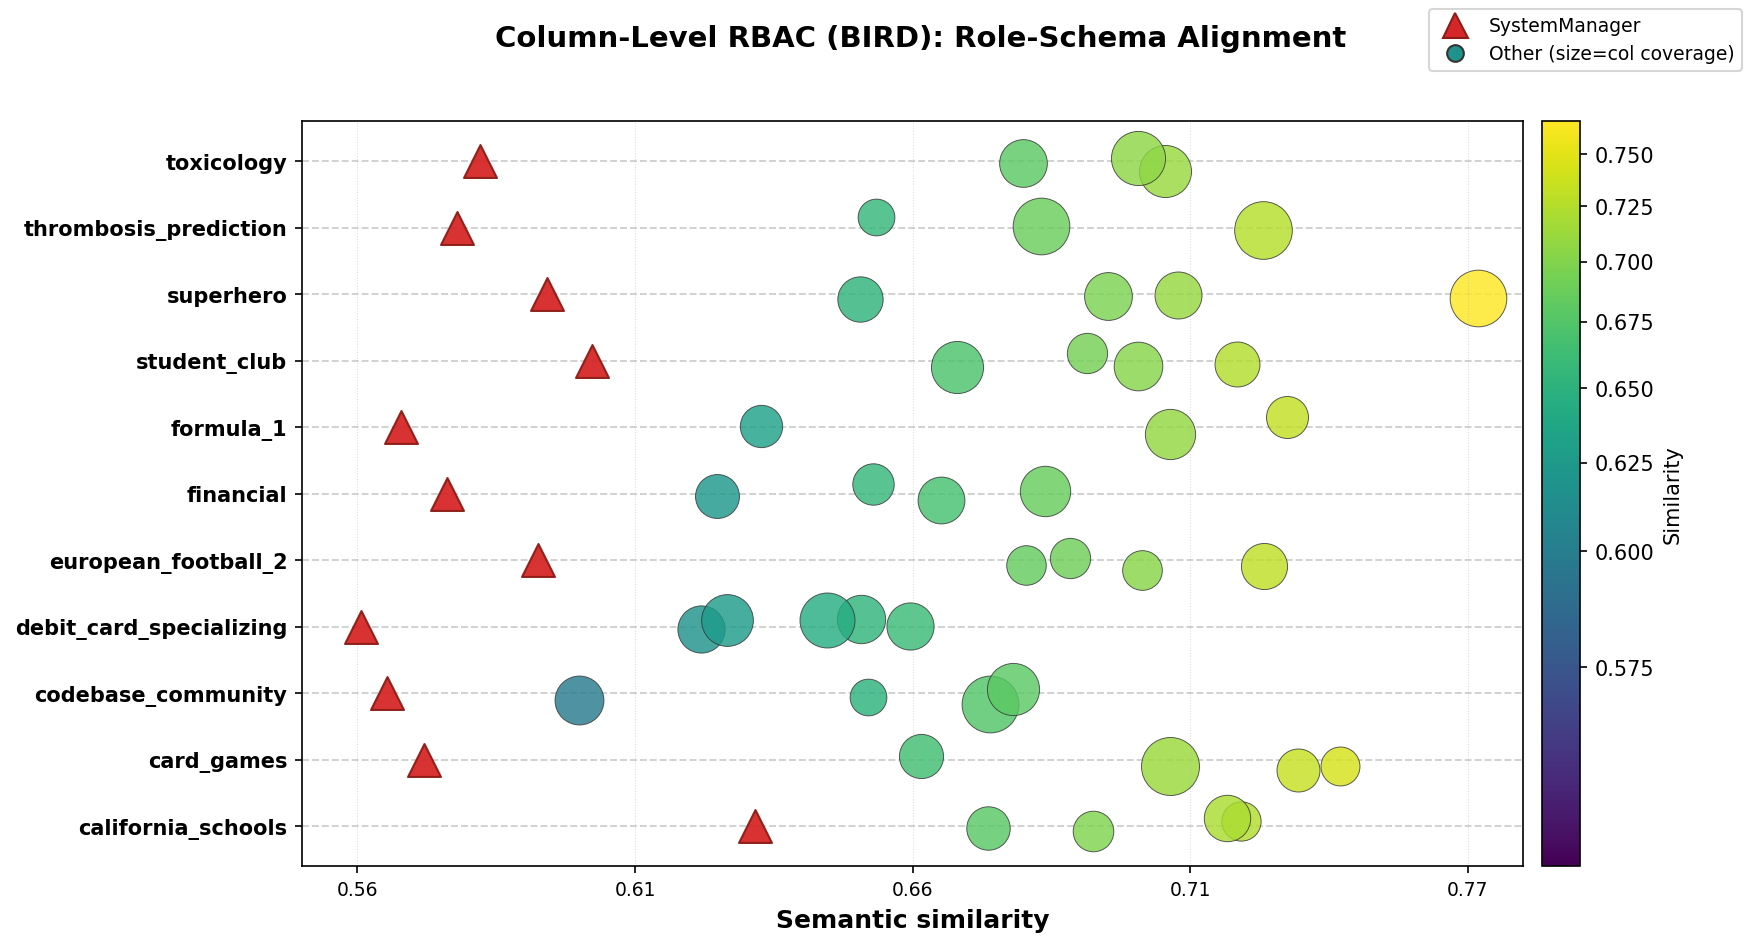

In [76]:
# 5.4 Semantic Alignment Visualization (Column-Level RBAC)
# Circle size = column coverage, Red triangles = SystemManager
import random
import math
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from matplotlib import colormaps as cm
from collections import defaultdict
from matplotlib.lines import Line2D
import numpy as np

sys.path.insert(0, str(project_root / "plot"))
from embedding_utils import cosine_similarity

# Prepare records (recompute)
role_records = evaluator._prepare_role_records()
evaluator._compute_embeddings()

# Build vis_records with is_system_manager
vis_records = []
for spec in role_records:
    schema_emb = evaluator._schema_emb_dict.get(spec["schema_text"])
    role_emb = evaluator._role_emb_dict.get(spec["role_text"])
    
    if schema_emb is not None and role_emb is not None:
        raw_sim = cosine_similarity(role_emb, schema_emb)
        similarity = max(0.0, min(1.0, (raw_sim + 1.0) / 2.0))
    else:
        similarity = 0.5
    
    total_cols = spec.get("total_columns", 1)
    accessible_cols = spec.get("accessible_columns", 0)
    col_coverage = accessible_cols / total_cols if total_cols > 0 else 0
    
    vis_records.append({
        "db_id": spec["db_id"],
        "role": spec["role"],
        "similarity": similarity,
        "is_system_manager": spec.get("is_system_manager", False),
        "column_coverage": col_coverage,
    })

sm_count = sum(1 for r in vis_records if r["is_system_manager"])
print(f"Total roles: {len(vis_records)}, SystemManager: {sm_count}")

# Plot function
def plot_semantic(records, output_path, title, dbs_per_panel=12):
    db_to_entries = defaultdict(list)
    sims = []
    for rec in records:
        sims.append(rec["similarity"])
        size = 90.0 + rec["column_coverage"] * 220.0
        db_to_entries[rec["db_id"]].append({
            "sim": rec["similarity"], "size": size,
            "is_sm": rec["is_system_manager"],
        })
    
    db_ids = sorted(db_to_entries.keys())
    panels = [db_ids[i:i+dbs_per_panel] for i in range(0, len(db_ids), dbs_per_panel)]
    
    min_s, max_s = min(sims), max(sims)
    if math.isclose(min_s, max_s): max_s = min_s + 1e-6
    span = max_s - min_s
    norm = PowerNorm(gamma=0.55, vmin=min_s, vmax=max_s)
    cmap = cm["viridis"]
    
    fig = plt.figure(figsize=(11, sum(0.35*len(p)+0.6 for p in panels)+2))
    gs = fig.add_gridspec(len(panels), 1, height_ratios=[0.35*len(p)+0.6 for p in panels], hspace=0.18)
    axes = []
    
    random.seed(42)
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    
    for pi, chunk in enumerate(panels):
        ax = fig.add_subplot(gs[pi, 0])
        axes.append(ax)
        for ri, db in enumerate(chunk):
            y = float(ri)
            ax.axhline(y, color="#d0d0d0", linestyle="--", lw=0.9, zorder=0)
            for e in db_to_entries[db]:
                x = (e["sim"] - min_s) / span + random.uniform(-0.012, 0.012)
                if e["is_sm"]:
                    ax.scatter(x, y, s=250, c="#d62728", alpha=0.95,
                               edgecolors="#8c1c15", lw=1.0, marker="^", zorder=4)
                else:
                    ax.scatter(x, y + random.uniform(-0.16, 0.16), s=e["size"]*2.5,
                               c=[e["sim"]], cmap=cmap, norm=norm, alpha=0.82,
                               edgecolors="#333", lw=0.45, marker="o")
        ax.set_yticks(range(len(chunk)))
        ax.set_yticklabels(chunk, fontsize=10, weight='bold')
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.6, len(chunk)-0.4)
        ax.set_xticks(np.linspace(0, 1, 5))
        ax.set_xticklabels([f"{min_s + p*span:.2f}" for p in np.linspace(0,1,5)], fontsize=9)
        ax.grid(axis="x", ls=":", lw=0.5, alpha=0.45)
    
    axes[-1].set_xlabel("Semantic similarity", fontsize=12, weight='bold')
    fig.suptitle(f"{title}: Role-Schema Alignment", fontsize=14, y=0.98, weight='bold')
    cbar = fig.colorbar(sm, ax=axes, fraction=0.03, pad=0.015)
    cbar.set_label("Similarity", fontsize=10)
    
    legend = [
        Line2D([0],[0], marker='^', color='w', markerfacecolor='#d62728',
               markeredgecolor='#8c1c15', markersize=12, label='SystemManager'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#21918c',
               markeredgecolor='#333', markersize=8, label='Other (size=col coverage)'),
    ]
    fig.legend(handles=legend, loc='upper right', fontsize=9)
    plt.tight_layout(rect=[0,0,0.95,0.95])
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved: {output_path}")

output_path = project_root / "plot" / "column_level_rbac_semantic.png"
plot_semantic(vis_records, output_path, "Column-Level RBAC (BIRD)")
from IPython.display import Image, display
display(Image(filename=str(output_path)))

In [13]:
# 5.5 Export Problematic Databases as DataFrame
if report.databases_with_issues:
    issues_data = []
    for db_id in report.databases_with_issues:
        row = {"Database": db_id}
        
        if db_id in report.deny_rate_metrics:
            m = report.deny_rate_metrics[db_id]
            row["Deny%"] = f"{m.deny_rate:.1f}%"
            row["AllAllow%"] = f"{m.all_allow_pct:.1f}%"
        
        if db_id in report.semantic_metrics:
            m = report.semantic_metrics[db_id]
            row["Coverage"] = f"{m.avg_coverage:.1%}"  # Source of "Most roles too permissive" (>90%)
            row["CovStd"] = f"{m.coverage_std:.3f}"    # Source of "Low role diversity" (<0.1)
        
        if db_id in report.overlap_metrics:
            m = report.overlap_metrics[db_id]
            row["MaxOverlap"] = f"{m.max_overlap:.1%}"  # Source of "High max overlap" (>70%)
        
        row["Issues"] = "; ".join(report.all_issues.get(db_id, []))
        issues_data.append(row)
    
    issues_df = pd.DataFrame(issues_data)
    print(f"=== Databases Requiring Review ({len(issues_df)}/{report.total_databases}) ===")
    
    # Display with full column width for Issues column
    pd.set_option('display.max_colwidth', None)
    pd.set_option('display.max_rows', None)
    display(issues_df)
    pd.reset_option('display.max_colwidth')
    pd.reset_option('display.max_rows')
    
    print("\nIssue Thresholds:")
    print("  - Deny% < 5%: roles too permissive")
    print("  - Coverage > 85%: most roles have near-full access")
    print("  - CovStd < 0.065: roles have similar coverage (low diversity)")
    print("  - MaxOverlap >80%: redundant roles with similar policies")

else:
    print("[OK] All databases pass quality checks!")

=== Databases Requiring Review (1/11) ===


,Database,Deny%,AllAllow%,Coverage,CovStd,MaxOverlap,Issues
0,california_schools,63.1%,5.6%,50.8%,0.059,72.3%,all-deny queries found (1) - SystemManager coverage broken; Low role diversity



Issue Thresholds:
  - Deny% < 5%: roles too permissive
  - Coverage > 85%: most roles have near-full access
  - CovStd < 0.065: roles have similar coverage (low diversity)
  - MaxOverlap >80%: redundant roles with similar policies


## 6. Regenerate Roles for Problematic Databases

Human-in-the-loop workflow for fixing quality issues:

| Step | Cell | Description |
|------|------|-------------|
| 1 | 6.1 | Select database, view schema and current roles |
| 2 | 6.2 | Write regeneration hints (edit manually) |
| 3 | 6.3 | Execute regeneration with LLM |
| 4 | 6.4 | Preview and compare OLD vs NEW |
| 5 | 6.4.1 | Select & combine roles from OLD and NEW |
| 6 | 6.5 | Apply changes if satisfied |
| 7 | 6.6 | Regenerate RBAC Dataset with updated roles |

In [32]:
# 6.1 Select Database(s) & View Current State
# Supports single db (str) or multiple dbs (list)

TARGET_DBS = ["formula_1"]  # Single: "toxicology" or Multiple: ["toxicology", "california_schools"]

# Normalize to list
if isinstance(TARGET_DBS, str):
    TARGET_DBS = [TARGET_DBS]

# Load current role assignments
with open(ROLE_ASSIGNMENTS_PATH, 'r') as f:
    all_assignments = json.load(f)

available_dbs = set(all_assignments.get('assignments', {}).keys())
valid_target_dbs = [db for db in TARGET_DBS if db in available_dbs]
invalid_dbs = [db for db in TARGET_DBS if db not in available_dbs]

if invalid_dbs:
    print(f"[WARN] Databases not found: {invalid_dbs}")
    print(f"Available: {sorted(available_dbs)}\n")

# Store schemas for later use
target_schemas = {}

for TARGET_DB in valid_target_dbs:
    print(f"\n{'='*70}")
    print(f"Database: {TARGET_DB}")
    print(f"{'='*70}")
    
    # --- Schema Summary ---
    db_path = bird_db_dir / TARGET_DB / f"{TARGET_DB}.sqlite"
    if db_path.exists():
        target_schema = get_schema_from_sqlite(str(db_path))
        target_schemas[TARGET_DB] = target_schema
        
        schema_rows = []
        for table, info in target_schema.items():
            for col in info['columns']:
                schema_rows.append({
                    "Table": table,
                    "Column": col['name'],
                    "Type": col['type'],
                    "PK": "Yes" if col['pk'] else "",
                    "FK": col.get('fk', '') or ""
                })
        
        schema_df = pd.DataFrame(schema_rows)
        print(f"\n=== Schema ({len(target_schema)} tables, {len(schema_df)} columns) ===")
        display(schema_df)
    else:
        print(f"[ERROR] Database not found: {db_path}")
        target_schemas[TARGET_DB] = None
        continue

    # --- Current Roles ---
    if TARGET_DB in all_assignments.get('assignments', {}):
        current_roles = all_assignments['assignments'][TARGET_DB]
        
        # Set display options for full content
        pd.set_option('display.max_colwidth', None)
        
        roles_rows = []
        for role_info in current_roles:
            policy = role_info.get('policy', {})
            total_access = count_policy_columns(policy, target_schema)
            has_wildcard = has_wildcard_policy(policy)
            cols_display = f"{total_access}" + (" (*)" if has_wildcard else "")
            # Full policy string
            policy_str = "; ".join([
                f"{t}: [{', '.join(c) if isinstance(c, list) else c}]" 
                for t, c in policy.items()
            ])
            roles_rows.append({
                "Role": role_info['role'],
                "Description": role_info.get('description', ''),
                "Tables": len(policy),
                "Columns": cols_display,
                "Policy": policy_str
            })
        
        roles_df = pd.DataFrame(roles_rows)
        print(f"\n=== Current Roles ({len(current_roles)}) ===")
        display(roles_df)
        
        pd.reset_option('display.max_colwidth')
        
        # Policy detail matrix
        policy_rows = []
        for role_info in current_roles:
            policy = role_info.get('policy', {})
            for table, cols in policy.items():
                num_cols = count_policy_columns({table: cols}, target_schema)
                policy_rows.append({
                    "Role": role_info['role'],
                    "Table": table,
                    "NumCols": num_cols
                })
        
        if policy_rows:
            policy_df = pd.DataFrame(policy_rows)
            pivot = policy_df.pivot_table(index='Role', columns='Table', values='NumCols', fill_value=0)
            print("\n=== Role x Table Matrix (column counts, * expanded) ===")
            display(pivot.style.background_gradient(cmap='Blues', axis=None))
        
        # Quality issues
        if 'report' in dir() and TARGET_DB in report.all_issues:
            print(f"\n=== Quality Issues ===")
            issues = report.all_issues[TARGET_DB]
            if TARGET_DB in report.deny_rate_metrics:
                m = report.deny_rate_metrics[TARGET_DB]
                issues_df = pd.DataFrame([{
                    "Deny Rate": f"{m.deny_rate:.1f}%",
                    "All-Allow %": f"{m.all_allow_pct:.1f}%",
                    "Issues": "; ".join(issues)
                }])
                display(issues_df)
    else:
        print(f"[ERROR] No roles found for {TARGET_DB}")

if valid_target_dbs:
    print(f"\n{'='*70}")
    print(f"[SUMMARY] {len(valid_target_dbs)} database(s) selected: {valid_target_dbs}")
    print("[NEXT] Edit hints in Cell 6.2, then run Cell 6.3")
else:
    print("[INFO] No databases selected. Edit TARGET_DBS above and re-run.")


Database: formula_1

=== Schema (13 tables, 94 columns) ===


,Table,Column,Type,PK,FK
0,circuits,circuitId,INTEGER,Yes,
1,circuits,circuitRef,TEXT,,
2,circuits,name,TEXT,,
3,circuits,location,TEXT,,
4,circuits,country,TEXT,,
...,...,...,...,...,...
89,results,fastestLap,INTEGER,,
90,results,rank,INTEGER,,
91,results,fastestLapTime,TEXT,,
92,results,fastestLapSpeed,TEXT,,



=== Current Roles (5) ===


,Role,Description,Tables,Columns,Policy
0,RaceAnalyst,"Analyzes race performance data including lap times, pit stops, and qualifying results",9,65 (*),"circuits: [circuitId, name, location, country, lat, lng]; constructors: [constructorId, constructorRef, name, nationality]; drivers: [driverId, driverRef, number, code, forename, surname, nationality]; races: [raceId, year, round, circuitId, name, date, time]; lapTimes: [*]; pitStops: [*]; qualifying: [*]; results: [resultId, raceId, driverId, constructorId, number, grid, position, positionOrder, points, laps, time, milliseconds, fastestLap, rank, fastestLapTime, fastestLapSpeed, statusId]; status: [statusId, status]"
1,StandingsManager,Manages championship standings and constructor/driver points calculations,7,43 (*),"constructors: [constructorId, constructorRef, name, nationality]; drivers: [driverId, driverRef, number, code, forename, surname, nationality]; races: [raceId, year, round, circuitId, name, date]; constructorResults: [*]; constructorStandings: [*]; driverStandings: [*]; results: [resultId, raceId, driverId, constructorId, position, positionOrder, points]"
2,MediaCoordinator,Provides public information for media and fan engagement,6,33 (*),"circuits: [circuitId, name, location, country, lat, lng, alt, url]; constructors: [constructorId, constructorRef, name, nationality, url]; drivers: [driverId, driverRef, number, code, forename, surname, nationality, url]; seasons: [*]; races: [raceId, year, round, circuitId, name, date, time, url]; status: [statusId, status]"
3,DriverManager,Manages driver information and personal details including date of birth,4,32 (*),"drivers: [*]; races: [raceId, year, round, name, date]; results: [resultId, raceId, driverId, constructorId, number, grid, position, positionOrder, points, laps, statusId]; driverStandings: [driverStandingsId, raceId, driverId, points, position, positionText, wins]"
4,SystemManager,Full administrative access for system maintenance and data integrity,13,94 (*),circuits: [*]; constructors: [*]; drivers: [*]; seasons: [*]; races: [*]; constructorResults: [*]; constructorStandings: [*]; driverStandings: [*]; lapTimes: [*]; pitStops: [*]; qualifying: [*]; status: [*]; results: [*]



=== Role x Table Matrix (column counts, * expanded) ===


Table,circuits,constructorResults,constructorStandings,constructors,driverStandings,drivers,lapTimes,pitStops,qualifying,races,results,seasons,status
Role,,,,,,,,,,,,,
DriverManager,0.000000,0.000000,0.000000,0.000000,7.000000,9.000000,0.000000,0.000000,0.000000,5.000000,11.000000,0.000000,0.000000
MediaCoordinator,8.000000,0.000000,0.000000,5.000000,0.000000,8.000000,0.000000,0.000000,0.000000,8.000000,0.000000,2.000000,2.000000
RaceAnalyst,6.000000,0.000000,0.000000,4.000000,0.000000,7.000000,6.000000,7.000000,9.000000,7.000000,17.000000,0.000000,2.000000
StandingsManager,0.000000,5.000000,7.000000,4.000000,7.000000,7.000000,0.000000,0.000000,0.000000,6.000000,7.000000,0.000000,0.000000
SystemManager,9.000000,5.000000,7.000000,5.000000,7.000000,9.000000,6.000000,7.000000,9.000000,8.000000,18.000000,2.000000,2.000000



[SUMMARY] 1 database(s) selected: ['formula_1']
[NEXT] Edit hints in Cell 6.2, then run Cell 6.3


In [34]:
# 6.2 Write Regeneration Hints (Human-in-the-Loop)
# Write ONE shared hint for all selected databases (they have similar issues)

# ============================================================
# EDIT HERE: Shared problem description for all selected DBs
# Supports {db}, {num_tables}, {num_cols} placeholders
# ============================================================
# PROBLEM_TO_FIX = """
# [PROBLEM]
# Low deny rate - almost all queries are allowed by all roles (roles too permissive)
# Low diversity - all roles have similar access patterns (coverage_std too low)


# [ROOT CAUSE]
# - Most roles can access most/all columns, so very few queries get denied
# - This defeats the purpose of RBAC - no meaningful access control

# [DIRECTION]
# - Database: {db} ({num_tables} tables, {num_cols} columns)
# - Create restrictive roles that only access specific subsets of data
# - Each role should have a clear, limited scope
# - Some roles should be restricted to fewer tables
# - Do not frequently giving non-admin roles "*" (all columns) access
# - Create clear functional boundaries between roles
# """

# All-denied cases - even SystemManager role cannot access some columns
# - Ensure SystemManager role has full access to all tables and columns


PROBLEM_TO_FIX = """
[PROBLEM]
Low semantic alignment - roles do not align well with schema
All-denied cases - even SystemManager role cannot access some columns

[ROOT CAUSE]
- This defeats the purpose of RBAC - no meaningful access control

[DIRECTION]
- Database: {db} ({num_tables} tables, {num_cols} columns)
- Ensure SystemManager role has full access to all tables and columns
- Review other roles to ensure they align with specific functional areas
- Each role should have a clear, limited scope
- Create meaningful semantic role names and descriptions that reflect their access patterns
"""


# PROBLEM_TO_FIX = """
# [PROBLEM]
# Low diversity - all roles have similar access patterns (coverage_std too low)

# [ROOT CAUSE]
# - This defeats the purpose of RBAC - no meaningful access control differentiation

# [DIRECTION]
# - Database: {db} ({num_tables} tables, {num_cols} columns)
# - Create restrictive roles that only access specific subsets of data
# - Each role should have a clear, limited scope
# - Some roles should be restricted to fewer tables
# - Do not frequently giving non-admin roles "*" (all columns) access
# - Create clear functional boundaries between roles
# """


# ============================================================
# Auto-apply to all selected databases (no need to edit below)
# ============================================================
REGENERATION_HINTS = {}

if valid_target_dbs:
    print(f"=== Applying shared hint to {len(valid_target_dbs)} database(s) ===\n")
    for db in valid_target_dbs:
        schema = target_schemas.get(db, {})
        num_tables = len(schema)
        num_cols = sum(len(t['columns']) for t in schema.values())
        
        # Fill placeholders
        REGENERATION_HINTS[db] = PROBLEM_TO_FIX.format(
            db=db, num_tables=num_tables, num_cols=num_cols
        )
        print(f"  ✓ {db}: {num_tables} tables, {num_cols} columns")

    print(f"\n[NEXT] Run Cell 6.3 to regenerate all {len(valid_target_dbs)} database(s)")
else:
    print("[INFO] No databases selected. Run Cell 6.1 first.")

=== Applying shared hint to 1 database(s) ===

  ✓ formula_1: 13 tables, 94 columns

[NEXT] Run Cell 6.3 to regenerate all 1 database(s)


In [68]:
# 6.3 Execute Regeneration with Hints (supports multiple databases)

def regenerate_single_database(db_name: str, hint: str) -> dict:
    """Regenerate roles for a single database with guidance hints."""
    db_path = bird_db_dir / db_name / f"{db_name}.sqlite"
    
    if not db_path.exists():
        return {"database": db_name, "status": "error", "error": "Database not found"}
    
    try:
        db_schema = get_schema_from_sqlite(str(db_path))
        db_schema_text = format_schema_for_prompt(db_schema, db_name)
        
        enhanced_system_prompt = f"{COLUMN_LEVEL_SYSTEM_PROMPT}\n\n[OPTIMIZATION GUIDANCE]\n{hint}"
        user_prompt = COLUMN_LEVEL_USER_PROMPT_TEMPLATE.format(schema_content=db_schema_text)
        
        response = oracle.query(
            prompt_sys=enhanced_system_prompt,
            prompt_user=user_prompt,
            temp=0.3,
            top_p=0.9,
            max_completion_tokens=DEFAULT_MAX_TOKENS
        )
        
        llm_response = response['answer']
        usage = response.get('usage', {})
        roles = parse_column_level_roles(llm_response)
        
        if not roles:
            return {"database": db_name, "status": "parse_error", 
                    "error": "Failed to parse LLM response", "raw_response": llm_response[:500]}
        
        validation = validate_roles_against_schema(roles, str(db_path))
        assignments = [{"role": r["role"], "description": r.get("description", ""), 
                       "policy": r.get("columns", {})} for r in roles]
        
        return {"database": db_name, "status": "success", "roles_count": len(assignments),
                "valid_roles": validation['valid_roles'], "all_valid": validation['all_valid'],
                "assignments": assignments, "usage": usage, "raw_response": llm_response}
    except Exception as e:
        return {"database": db_name, "status": "error", "error": str(e)}

# Execute for all target databases
if valid_target_dbs:
    print(f"Regenerating roles for {len(valid_target_dbs)} database(s)...")
    print("="*60)

    regenerated_results = {}  # Store all results
    all_success = True

    for db_name in valid_target_dbs:
        hint = REGENERATION_HINTS.get(db_name, PROBLEM_TO_FIX)
        print(f"\n[{db_name}] Generating...")
        
        result = regenerate_single_database(db_name, hint)
        regenerated_results[db_name] = result
        
        if result["status"] == "success":
            print(f"  ✓ {result['roles_count']} roles ({result['valid_roles']} valid)")
        else:
            print(f"  ✗ {result.get('error', result['status'])}")
            all_success = False

    # Summary table
    print("\n" + "="*60)
    result_df = pd.DataFrame([{
        "Database": r["database"],
        "Status": r["status"],
        "Roles": r.get("roles_count", "N/A"),
        "Valid": r.get("valid_roles", "N/A"),
        "Tokens": r.get("usage", {}).get("total_tokens", "N/A")
    } for r in regenerated_results.values()])
    display(result_df)

    if all_success:
        print("\n[OK] All databases regenerated. Run Cell 6.4 to preview.")
    else:
        print("\n[WARN] Some databases failed. Check errors above.")
else:
    regenerated_results = {}
    print("[INFO] No databases selected. Run Cell 6.1 first.")

Regenerating roles for 1 database(s)...

[formula_1] Generating...
  ✓ 5 roles (5 valid)



,Database,Status,Roles,Valid,Tokens
0,formula_1,success,5,5,3058



[OK] All databases regenerated. Run Cell 6.4 to preview.


In [69]:
# 6.4 Preview Regenerated Roles (Compare OLD vs NEW + Quality Check)
# Supports multiple databases
import numpy as np
from src.role_evaluator.quality_metrics import RoleQualityEvaluator

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

if 'regenerated_results' in dir() and regenerated_results:
    for db_name, regen_result in regenerated_results.items():
        if regen_result["status"] != "success":
            print(f"\n{'='*70}")
            print(f"[SKIP] {db_name}: {regen_result.get('error', 'failed')}")
            continue
        
        regenerated_assignments = regen_result["assignments"]
        target_schema = target_schemas.get(db_name)
        
        print(f"\n{'='*70}")
        print(f"Database: {db_name}")
        print(f"{'='*70}")
        
        # --- NEW Role Summary ---
        new_summary = []
        for r in regenerated_assignments:
            policy = r.get('policy', {})
            total_cols = count_policy_columns(policy, target_schema)
            has_wc = has_wildcard_policy(policy)
            cols_display = f"{total_cols}" + (" (*)" if has_wc else "")
            policy_str = "; ".join([
                f"{t}: [{', '.join(c) if isinstance(c, list) else c}]" 
                for t, c in policy.items()
            ])
            new_summary.append({
                "Role": r['role'],
                "Description": r.get('description', ''),
                "Tables": len(policy),
                "Cols": cols_display,
                "Policy": policy_str
            })
        
        print(f"\n=== NEW Roles ({len(regenerated_assignments)}) ===")
        display(pd.DataFrame(new_summary))
        
        # --- Quality Metrics ---
        if target_schema:
            total_schema_cols = sum(len(t['columns']) for t in target_schema.values())
        else:
            total_schema_cols = 10
        
        # NEW metrics
        new_coverages = [count_policy_columns(r.get('policy', {}), target_schema) / total_schema_cols 
                        for r in regenerated_assignments]
        new_avg_cov = np.mean(new_coverages)
        new_cov_std = np.std(new_coverages)
        
        new_max_overlap = 0.0
        non_admin_new = [r for r in regenerated_assignments if 'admin' not in r['role'].lower()]
        for i, r1 in enumerate(non_admin_new):
            set1 = RoleQualityEvaluator.policy_to_column_set(r1.get('policy', {}))
            for r2 in non_admin_new[i+1:]:
                set2 = RoleQualityEvaluator.policy_to_column_set(r2.get('policy', {}))
                new_max_overlap = max(new_max_overlap, RoleQualityEvaluator.jaccard_similarity(set1, set2))
        
        # OLD metrics
        old_roles = all_assignments.get('assignments', {}).get(db_name, [])
        if old_roles:
            old_coverages = [count_policy_columns(r.get('policy', {}), target_schema) / total_schema_cols 
                           for r in old_roles]
            old_avg_cov = np.mean(old_coverages)
            old_cov_std = np.std(old_coverages)
            
            old_max_overlap = 0.0
            non_admin_old = [r for r in old_roles if 'admin' not in r['role'].lower()]
            for i, r1 in enumerate(non_admin_old):
                set1 = RoleQualityEvaluator.policy_to_column_set(r1.get('policy', {}))
                for r2 in non_admin_old[i+1:]:
                    set2 = RoleQualityEvaluator.policy_to_column_set(r2.get('policy', {}))
                    old_max_overlap = max(old_max_overlap, RoleQualityEvaluator.jaccard_similarity(set1, set2))
        else:
            old_avg_cov, old_cov_std, old_max_overlap = 0, 0, 0
        
        # Comparison table (using QUALITY_THRESHOLDS from Cell 5.1)
        def status(metric, val):
            if metric == "Coverage": 
                return "WARN" if val > QUALITY_THRESHOLDS.get("coverage_max", 0.90) else "OK"
            if metric == "CovStd": 
                return "WARN" if val < QUALITY_THRESHOLDS.get("coverage_std_min", 0.08) else "OK"
            if metric == "MaxOverlap": 
                return "WARN" if val > QUALITY_THRESHOLDS.get("max_overlap", 0.80) else "OK"
            return "OK"
        
        quality_df = pd.DataFrame([
            {"Metric": "Roles", "OLD": len(old_roles), "NEW": len(regenerated_assignments)},
            {"Metric": "Avg Coverage", "OLD": f"{old_avg_cov:.1%}", "NEW": f"{new_avg_cov:.1%}", 
             "Threshold": f"<{QUALITY_THRESHOLDS.get('coverage_max', 0.90):.0%}",
             "Status": status("Coverage", new_avg_cov)},
            {"Metric": "Coverage Std", "OLD": f"{old_cov_std:.3f}", "NEW": f"{new_cov_std:.3f}",
             "Threshold": f">{QUALITY_THRESHOLDS.get('coverage_std_min', 0.08)}",
             "Status": status("CovStd", new_cov_std)},
            {"Metric": "Max Overlap", "OLD": f"{old_max_overlap:.1%}", "NEW": f"{new_max_overlap:.1%}",
             "Threshold": f"<{QUALITY_THRESHOLDS.get('max_overlap', 0.80):.0%}",
             "Status": status("MaxOverlap", new_max_overlap)},
        ])
        print("\n=== Quality Comparison ===")
        display(quality_df)
        
        warn_count = quality_df['Status'].eq('WARN').sum() if 'Status' in quality_df.columns else 0
        if warn_count == 0:
            print(f"[OK] {db_name}: All quality checks passed")
        else:
            print(f"[WARN] {db_name}: {warn_count} issue(s)")
    
    print(f"\n{'='*70}")
    print("[DECISION] Satisfied? Run Cell 6.5 to apply. Otherwise edit Cell 6.2 and re-run 6.3.")
    print("[TIP] Use Cell 6.4.1 to select specific roles from OLD/NEW")
else:
    print("[WARN] No regenerated results. Run Cell 6.3 first.")

pd.reset_option('display.max_colwidth')
pd.reset_option('display.max_rows')
pd.reset_option('display.width')


Database: formula_1

=== NEW Roles (5) ===


,Role,Description,Tables,Cols,Policy
0,SystemManager,Full administrative access for system maintenance and data management,13,94 (*),circuits: [*]; constructors: [*]; drivers: [*]; seasons: [*]; races: [*]; constructorResults: [*]; constructorStandings: [*]; driverStandings: [*]; lapTimes: [*]; pitStops: [*]; qualifying: [*]; status: [*]; results: [*]
1,RaceAnalyst,"Analyzes race performance data including lap times, pit stops, and qualifying results",8,61,"circuits: [circuitId, name, location, country, lat, lng]; constructors: [constructorId, name, nationality]; drivers: [driverId, driverRef, number, code, forename, surname, nationality]; races: [raceId, year, round, circuitId, name, date]; lapTimes: [raceId, driverId, lap, position, time, milliseconds]; pitStops: [raceId, driverId, stop, lap, time, duration, milliseconds]; qualifying: [qualifyId, raceId, driverId, constructorId, number, position, q1, q2, q3]; results: [resultId, raceId, driverId, constructorId, number, grid, position, positionOrder, points, laps, time, milliseconds, fastestLap, rank, fastestLapTime, fastestLapSpeed, statusId]"
2,StandingsManager,Manages and monitors championship standings for drivers and constructors,7,42,"constructors: [constructorId, name, nationality]; drivers: [driverId, driverRef, number, code, forename, surname, nationality]; races: [raceId, year, round, name, date]; constructorResults: [constructorResultsId, raceId, constructorId, points, status]; constructorStandings: [constructorStandingsId, raceId, constructorId, points, position, positionText, wins]; driverStandings: [driverStandingsId, raceId, driverId, points, position, positionText, wins]; results: [resultId, raceId, driverId, constructorId, points, position, positionText, statusId]"
3,PublicRelations,"Accesses public information about circuits, drivers, constructors, and race schedules",6,31,"circuits: [circuitId, name, location, country, lat, lng, alt, url]; constructors: [constructorId, name, nationality, url]; drivers: [driverId, driverRef, number, code, forename, surname, nationality, url]; seasons: [year, url]; races: [raceId, year, round, circuitId, name, date, url]; status: [statusId, status]"
4,DriverManager,Manages driver information and personal details including date of birth,4,32,"drivers: [driverId, driverRef, number, code, forename, surname, dob, nationality]; races: [raceId, year, round, name, date]; driverStandings: [driverStandingsId, raceId, driverId, points, position, positionText, wins]; results: [resultId, raceId, driverId, constructorId, number, grid, position, positionText, positionOrder, points, laps, statusId]"



=== Quality Comparison ===


,Metric,OLD,NEW,Threshold,Status
0,Roles,5,5,NaN,NaN
1,Avg Coverage,65.5%,55.3%,<85%,OK
2,Coverage Std,0.183,0.251,>0.065,OK
3,Max Overlap,87.3%,57.4%,<80%,OK


[OK] formula_1: All quality checks passed

[DECISION] Satisfied? Run Cell 6.5 to apply. Otherwise edit Cell 6.2 and re-run 6.3.
[TIP] Use Cell 6.4.1 to select specific roles from OLD/NEW


In [70]:
# 6.4.1 Select & Combine Roles from OLD and NEW
# Human expert picks best roles from both versions to create final role set

# ============================================================
# EDIT HERE: Specify which roles to keep from each version
# Format: {"db_name": {"old": [role_names], "new": [role_names]}}
# Leave empty [] to skip a version, or use ["*"] to keep all from that version
# ============================================================
ROLE_SELECTION = {
    "formula_1": {
        "old": [],  # e.g., ["DataAnalyst", "Researcher"]
        "new": ["SystemManager", "RaceAnalyst", "PublicRelations", "DriverManager"],  # keep all new roles
    },
    # "financial": {
    #     "old": [],
    #     "new": ["*"],
    # },
}

# ============================================================
# Process selections and create combined role sets
# ============================================================
combined_results = {}

if 'regenerated_results' in dir() and regenerated_results:
    print("=== Role Selection Summary ===\n")
    
    for db_name in valid_target_dbs:
        selection = ROLE_SELECTION.get(db_name, {"old": [], "new": ["*"]})
        old_keep = selection.get("old", [])
        new_keep = selection.get("new", ["*"])
        
        # Get OLD roles
        old_roles = all_assignments.get('assignments', {}).get(db_name, [])
        old_role_dict = {r['role']: r for r in old_roles}
        
        # Get NEW roles
        regen_result = regenerated_results.get(db_name, {})
        if regen_result.get("status") != "success":
            print(f"[SKIP] {db_name}: regeneration failed")
            continue
        new_roles = regen_result["assignments"]
        new_role_dict = {r['role']: r for r in new_roles}
        
        # Build combined role set
        combined_roles = []
        selected_from_old = []
        selected_from_new = []
        
        # Select from OLD
        if old_keep == ["*"]:
            combined_roles.extend(old_roles)
            selected_from_old = [r['role'] for r in old_roles]
        else:
            for role_name in old_keep:
                if role_name in old_role_dict:
                    combined_roles.append(old_role_dict[role_name])
                    selected_from_old.append(role_name)
                else:
                    print(f"  [WARN] {db_name}: OLD role '{role_name}' not found")
        
        # Select from NEW
        if new_keep == ["*"]:
            combined_roles.extend(new_roles)
            selected_from_new = [r['role'] for r in new_roles]
        else:
            for role_name in new_keep:
                if role_name in new_role_dict:
                    combined_roles.append(new_role_dict[role_name])
                    selected_from_new.append(role_name)
                else:
                    print(f"  [WARN] {db_name}: NEW role '{role_name}' not found")
        
        combined_results[db_name] = combined_roles
        
        # Display summary
        print(f"{'='*60}")
        print(f"Database: {db_name}")
        print(f"  From OLD ({len(selected_from_old)}): {selected_from_old if selected_from_old else '(none)'}")
        print(f"  From NEW ({len(selected_from_new)}): {selected_from_new if selected_from_new else '(none)'}")
        print(f"  Combined: {len(combined_roles)} roles")
        
        # Show combined roles table
        target_schema = target_schemas.get(db_name)
        combined_summary = []
        for r in combined_roles:
            policy = r.get('policy', {})
            source = "OLD" if r['role'] in old_role_dict and r['role'] not in [nr['role'] for nr in new_roles] else "NEW"
            if r['role'] in old_role_dict and r['role'] in [nr['role'] for nr in new_roles]:
                source = "NEW"  # Prefer NEW if same name exists in both
            combined_summary.append({
                "Source": source,
                "Role": r['role'],
                "Description": r.get('description', ''),
                "Tables": len(policy),
                "Policy": "; ".join([f"{t}: [{', '.join(c) if isinstance(c, list) else c}]" for t, c in policy.items()])
            })
        
        display(pd.DataFrame(combined_summary))
        print()
    
    print("="*60)
    print(f"[NEXT] Run Cell 6.5 to apply combined role sets")
    print("[TIP] Edit ROLE_SELECTION above to customize, then re-run this cell")
else:
    print("[WARN] No regenerated results. Run Cell 6.3 first.")
    print("\n[HINT] Available roles to select from:")
    print("  OLD: roles from current assignments")
    print("  NEW: roles from regeneration")

=== Role Selection Summary ===

Database: formula_1
  From OLD (0): (none)
  From NEW (4): ['SystemManager', 'RaceAnalyst', 'PublicRelations', 'DriverManager']
  Combined: 4 roles


,Source,Role,Description,Tables,Policy
0,NEW,SystemManager,Full administrative access for system maintena...,13,circuits: [*]; constructors: [*]; drivers: [*]...
1,NEW,RaceAnalyst,Analyzes race performance data including lap t...,8,"circuits: [circuitId, name, location, country,..."
2,NEW,PublicRelations,"Accesses public information about circuits, dr...",6,"circuits: [circuitId, name, location, country,..."
3,NEW,DriverManager,Manages driver information and personal detail...,4,"drivers: [driverId, driverRef, number, code, f..."



[NEXT] Run Cell 6.5 to apply combined role sets
[TIP] Edit ROLE_SELECTION above to customize, then re-run this cell


In [71]:
# 6.5 Apply Changes (Save Combined Role Sets)
# Uses combined_results from Cell 6.4.1 (selected from OLD + NEW)
from datetime import datetime

APPLY_CHANGES = True  # Set to True to confirm

if APPLY_CHANGES:
    # Prefer combined_results (from selection), fallback to regenerated_results
    use_combined = 'combined_results' in dir() and combined_results
    use_regenerated = 'regenerated_results' in dir() and regenerated_results
    
    if use_combined:
        print("[MODE] Applying COMBINED role sets (from Cell 6.4.1 selection)\n")
        applied = []
        
        for db_name, combined_roles in combined_results.items():
            if not combined_roles:
                continue
            
            old_count = len(all_assignments.get('assignments', {}).get(db_name, []))
            all_assignments['assignments'][db_name] = combined_roles
            applied.append({
                "Database": db_name,
                "Old Roles": old_count,
                "New Roles": len(combined_roles),
                "Source": "Combined (OLD+NEW)"
            })
        
        if applied:
            OUTPUT_DIR = project_root / 'outputs'
            today = datetime.now().strftime('%Y%m%d')
            output_path = OUTPUT_DIR / f'bird_column_level_rbac_assignments_v2_{today}.json'
            with open(output_path, 'w') as f:
                json.dump(all_assignments, f, indent=2, ensure_ascii=False)
            
            print("=== Changes Applied ===")
            display(pd.DataFrame(applied))
            print(f"\nSaved to: {output_path.name}")
            
            # Clear state
            combined_results = {}
            regenerated_results = {}
            print("\n[OK] State cleared. Select new database(s) to continue.")
        else:
            print("[WARN] No combined role sets to apply. Run Cell 6.4.1 first.")
    
    elif use_regenerated:
        print("[MODE] Applying ALL NEW roles (no selection made)\n")
        applied = []
        
        for db_name, regen_result in regenerated_results.items():
            if regen_result["status"] != "success":
                continue
            
            old_count = len(all_assignments.get('assignments', {}).get(db_name, []))
            all_assignments['assignments'][db_name] = regen_result["assignments"]
            applied.append({
                "Database": db_name,
                "Old Roles": old_count,
                "New Roles": len(regen_result["assignments"]),
                "Source": "All NEW"
            })
        
        if applied:
            OUTPUT_DIR = project_root / 'outputs'
            today = datetime.now().strftime('%Y%m%d')
            output_path = OUTPUT_DIR / f'bird_column_level_rbac_assignments_v2_{today}.json'
            with open(output_path, 'w') as f:
                json.dump(all_assignments, f, indent=2, ensure_ascii=False)
            
            print("=== Changes Applied ===")
            display(pd.DataFrame(applied))
            print(f"\nSaved to: {output_path.name}")
            
            regenerated_results = {}
            print("\n[OK] State cleared. Select new database(s) to continue.")
        else:
            print("[WARN] No successful regenerations to apply.")
    else:
        print("[WARN] No results to apply. Run Cell 6.3 and optionally Cell 6.4.1 first.")
else:
    has_combined = 'combined_results' in dir() and combined_results
    has_regenerated = 'regenerated_results' in dir() and regenerated_results
    
    if has_combined:
        print(f"[INFO] {len(combined_results)} database(s) with COMBINED role sets ready")
        print("[TIP] These are your custom selections from OLD + NEW")
    elif has_regenerated:
        success_count = sum(1 for r in regenerated_results.values() if r["status"] == "success")
        print(f"[INFO] {success_count} database(s) with ALL NEW roles ready")
        print("[TIP] Run Cell 6.4.1 to select specific roles from OLD/NEW")
    
    print("\n[INFO] APPLY_CHANGES is False. Set to True and re-run to apply.")

[MODE] Applying COMBINED role sets (from Cell 6.4.1 selection)

=== Changes Applied ===


,Database,Old Roles,New Roles,Source
0,formula_1,5,4,Combined (OLD+NEW)



Saved to: bird_column_level_rbac_assignments_v2_20251230.json

[OK] State cleared. Select new database(s) to continue.


In [72]:
# 6.6 Regenerate RBAC Dataset with Updated Role Assignments
# Run this after Cell 6.5 to create the final dataset

from datetime import datetime
import importlib

# IMPORTANT: Reload ALL dependent modules to pick up CTE parsing fix
import src.processors.column_extractor
import src.processors.column_permission_checker
import src.processors.column_level_rbac_generator

importlib.reload(src.processors.column_extractor)
importlib.reload(src.processors.column_permission_checker)
importlib.reload(src.processors.column_level_rbac_generator)

from src.processors.column_level_rbac_generator import ColumnLevelRBACGenerator

# Find the updated role assignments file (v2 if exists, otherwise latest)
v2_files = sorted(glob.glob(str(project_root / 'outputs' / 'bird_column_level_rbac_assignments_v2_*.json')))
if v2_files:
    UPDATED_ROLE_PATH = v2_files[-1]
else:
    role_files = sorted(glob.glob(str(project_root / 'outputs' / 'column_level_role_assignments_bird_*.json')))
    UPDATED_ROLE_PATH = role_files[-1] if role_files else None

if UPDATED_ROLE_PATH:
    print(f"=== Regenerating RBAC Dataset ===")
    print(f"Role assignments: {Path(UPDATED_ROLE_PATH).name}")
    print(f"BIRD data: {BIRD_DATA_PATH}")
    
    # Initialize generator with updated roles
    generator = ColumnLevelRBACGenerator(
        role_assignments_path=UPDATED_ROLE_PATH,
        bird_data_path=str(BIRD_DATA_PATH),
        bird_db_root=str(BIRD_DB_ROOT),
        project_root=str(project_root),
        seed=42
    )
    
    # Generate dataset
    today = datetime.now().strftime('%Y%m%d')
    output_path = project_root / 'outputs' / f'column_level_rbac_dataset_bird_{today}.json'
    
    full_stats = generator.generate_and_save(
        output_path=str(output_path),
        roles_per_db=None,
        queries_per_role=None
    )
    
    print(f"\n✓ Dataset saved to: {output_path.name}")
    print(f"\n=== Dataset Statistics ===")
    for k, v in full_stats.items():
        if k == 'by_database':
            print(f"\nPer-database distribution:")
            for db_id, counts in sorted(v.items()):
                print(f"  {db_id}: allowed={counts['allowed']}, denied={counts['denied']}")
        else:
            print(f"  {k}: {v}")
else:
    print("[ERROR] No role assignments file found. Run Cell 6.5 first.")

=== Regenerating RBAC Dataset ===
Role assignments: bird_column_level_rbac_assignments_v2_20251230.json
BIRD data: /home/feiy/Role-SQL-benchmark/data/Bird/dev_20251106/dev.json
Generating column-level RBAC dataset...
  Roles per DB: None
  Queries per role: all
Current ratio (allowed): 50.41%
  Allowed: 3656, Denied: 3596

Dataset saved to /home/feiy/Role-SQL-benchmark/outputs/column_level_rbac_dataset_bird_20251230.json
Metadata saved to /home/feiy/Role-SQL-benchmark/outputs/column_level_rbac_dataset_bird_20251230_metadata.json
  Total entries: 7252
  Allowed: 3656 (50.4%)
  Denied: 3596 (49.6%)

✓ Dataset saved to: column_level_rbac_dataset_bird_20251230.json

=== Dataset Statistics ===
  total_entries: 7252
  allowed: 3656
  denied: 3596
  allowed_ratio: 0.5041367898510756

Per-database distribution:
  california_schools: allowed=118, denied=327
  card_games: allowed=507, denied=448
  codebase_community: allowed=578, denied=352
  debit_card_specializing: allowed=174, denied=210
  eu

## 7. Summary

### Generated Files
- `outputs/column_level_role_assignments_bird_YYYYMMDD.json` - Role assignments with column-level policies
- `outputs/bird_column_level_rbac_assignments_v2_YYYYMMDD.json` - Updated role assignments after regeneration
- `outputs/column_level_rbac_dataset_bird_YYYYMMDD.json` - Column-Level RBAC dataset

### Workflow

| Section | Description |
|---------|-------------|
| **3** | Batch process all BIRD databases to generate initial roles |
| **4** | Generate RBAC dataset from role assignments |
| **5** | Quality assessment with configurable thresholds |
| **6.1** | Select problematic database(s) and view current state |
| **6.2** | Write regeneration hints with problem description |
| **6.3** | Execute LLM regeneration with hints |
| **6.4** | Preview OLD vs NEW roles with quality comparison |
| **6.4.1** | Select & combine best roles from OLD and NEW |
| **6.5** | Apply changes (save updated role assignments) |
| **6.6** | Regenerate RBAC dataset with updated roles |

### Quality Assessment Module (Section 5)

```python
from src.role_evaluator import RoleQualityEvaluator, RoleQualityVisualizer

evaluator = RoleQualityEvaluator(
    role_assignments_path="outputs/column_level_role_assignments_bird.json",
    dataset_path="outputs/column_level_rbac_dataset_bird.json",
    schema_dir="data/Bird/dev_20251106/dev_databases",
    embed_model="BAAI/bge-small-en-v1.5"  # or "text-embedding-3-small"
)

report = evaluator.evaluate_all()
visualizer = RoleQualityVisualizer(evaluator=evaluator, report=report)
visualizer.plot_quality_dashboard()
```

### Quality Thresholds (Configurable)

| Metric | Default | Description |
|--------|---------|-------------|
| `deny_rate_min` | 5% | Warn if deny rate below (roles too permissive) |
| `coverage_max` | 90% | Warn if avg coverage above (roles too broad) |
| `coverage_std_min` | 0.08 | Warn if coverage std below (low diversity) |
| `max_overlap` | 80% | Warn if max overlap above (redundant roles) |

### External Modules

1. **`src/role_evaluator/quality_metrics.py`** - Quality metrics computation
   - `RoleQualityEvaluator`: Comprehensive evaluator
   - `DenyRateMetrics`, `SemanticMetrics`, `OverlapMetrics`: Data classes
   - `print_quality_report()`: Formatted report output

2. **`src/role_evaluator/quality_visualizer.py`** - Visualization suite
   - `plot_deny_rate_distribution()`: Permission distribution chart
   - `plot_semantic_alignment()`: Semantic alignment scatter plot
   - `plot_policy_overlap_bars()`: Policy overlap bar chart
   - `plot_quality_dashboard()`: Comprehensive dashboard

3. **`src/processors/column_level_rbac_generator.py`** - Dataset generation
   - `ColumnLevelRBACGenerator`: Generate RBAC dataset from role assignments